In [1]:
from PIL import Image
import numpy as np
from heat_experiment_2d import HeatExperiment2D
%matplotlib widget

In [2]:
im = Image.open(r"D:\Projects\Python\Palermo\2Dheat\vein_mask.bmp")
masks = ~np.array(im,dtype=bool)
src_val = 1
masks = src_val*masks

In [10]:
def fake_response_function(terminal_time, timestep):
    x = np.linspace(0, 0.5)
    y1 = 2*(1/(1+np.exp(-16*x))-0.5)
    x = np.linspace(-0.5, 0)
    y2 = -2*(1/(1+np.exp(-16*(x)))-0.5)
    y = np.append(y1, y2)
    x = np.linspace(0, 1, 100)
    
    t = np.arange(0, terminal_time, timestep)/terminal_time
    yt = np.interp(t, x, y)
    return yt

In [ ]:

# fake_response = fake_response_function(terminal_time=terminal, timestep=timestep)
# len(fake_response)


800

In [ ]:
terminal = 80
timestep = 0.1
exp1 = HeatExperiment2D(terminal_time=terminal, timestep=timestep, vein_function_values = fake_response_function(terminal, timestep),
                        length_x=0.1, length_y=0.1, boundary_value=0,
                        vein_masks = [masks], initial_value=0, cmap='cmr.arctic')



In [5]:
exp1.run_calculation()

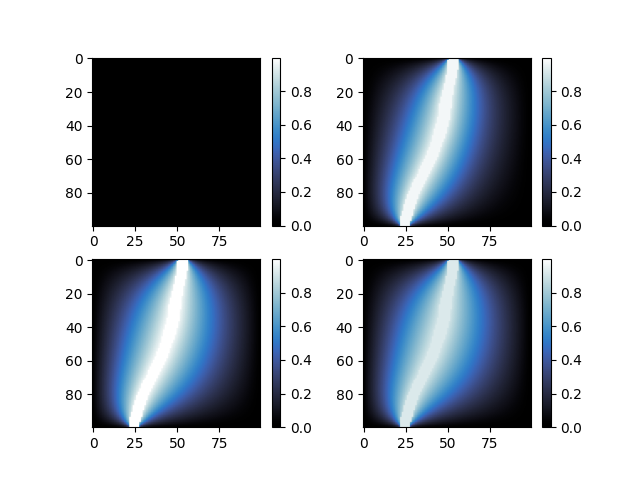

In [6]:
exp1.visualize_snapshots()

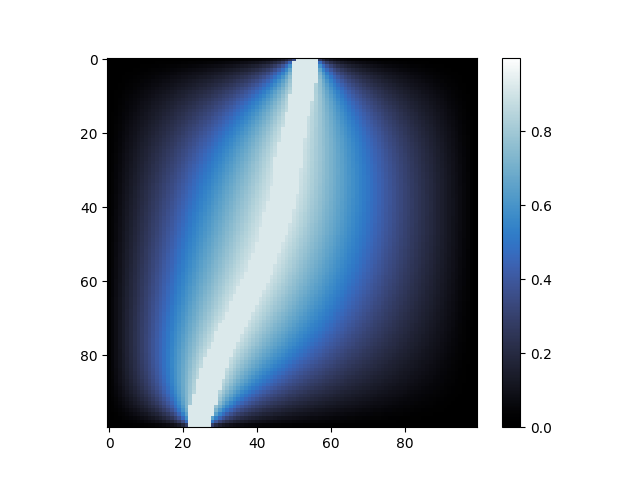

In [ ]:
exp1.visualize_animated(save=True)